Test the TaucPlot:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/ThermalCycling/Spectra_Playground/Spectra/20250918_202847_Thermal_Cycling_Spectrum_Light_c2299-1.dat'
darkFile = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/ThermalCycling/Spectra_Playground/Spectra/Dark/20250915_155012_Thermal_Cycling_Spectrum_dark_Dark.dat'
lightFile = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/ThermalCycling/Spectra_Playground/Spectra/Light/20250905_141323_Lamp_Cycle_Spectrum_Light_c000-2.dat'

In [3]:
def load_spectrum(path):
    return np.loadtxt(path, comments='#', usecols=(1, 2), unpack=True)

wavelength_Data, T_Data = load_spectrum(file)
wavelength_Dark, T_Dark = load_spectrum(darkFile)
wavelength_Light, T_Light = load_spectrum(lightFile)


In [4]:
print(T_Data)

[1773. 1766. 1808. 1774. 1791. 1798. 1763. 1792. 1783. 1750. 1795. 1763.
 1794. 1798. 1742. 1787. 1761. 1760. 1804. 1748. 1792. 1777. 1756. 1797.
 1772. 1764. 1791. 1780. 1778. 1780. 1775. 1797. 1785. 1768. 1801. 1778.
 1793. 1795. 1775. 1782. 1794. 1766. 1814. 1776. 1792. 1795. 1774. 1796.
 1788. 1783. 1827. 1787. 1820. 1805. 1759. 1829. 1805. 1823. 1862. 1797.
 1833. 1820. 1824. 1826. 1812. 1793. 1837. 1810. 1803. 1809. 1794. 1808.
 1784. 1781. 1822. 1774. 1801. 1821. 1767. 1814. 1816. 1783. 1838. 1783.
 1806. 1813. 1771. 1824. 1819. 1796. 1825. 1789. 1814. 1815. 1790. 1826.
 1808. 1791. 1834. 1788. 1809. 1819. 1787. 1829. 1806. 1796. 1839. 1780.
 1807. 1828. 1819. 1823. 1795. 1790. 1845. 1820. 1848. 1841. 1789. 1855.
 1823. 1833. 1866. 1795. 1849. 1853. 1840. 1864. 1848. 1842. 1882. 1835.
 1862. 1854. 1818. 1857. 1844. 1834. 1868. 1846. 1879. 1867. 1845. 1889.
 1861. 1853. 1885. 1836. 1871. 1875. 1848. 1881. 1874. 1850. 1899. 1849.
 1883. 1902. 1878. 1920. 1902. 1875. 1883. 1852. 18

In [5]:
wavelength = wavelength_Data
Trans = (T_Data-T_Dark)/(T_Light-T_Data)
absorbance = -np.log(Trans)

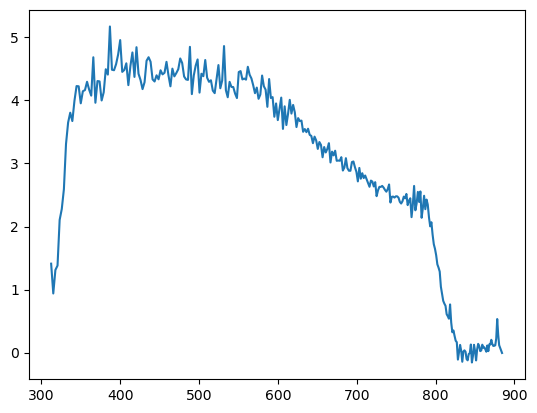

In [6]:
plt.plot(wavelength, absorbance)

In [7]:
tauc_x = 1240/wavelength

In [8]:
tauc_intensity = (absorbance * tauc_x) ** 2

(0.0, 20.0)

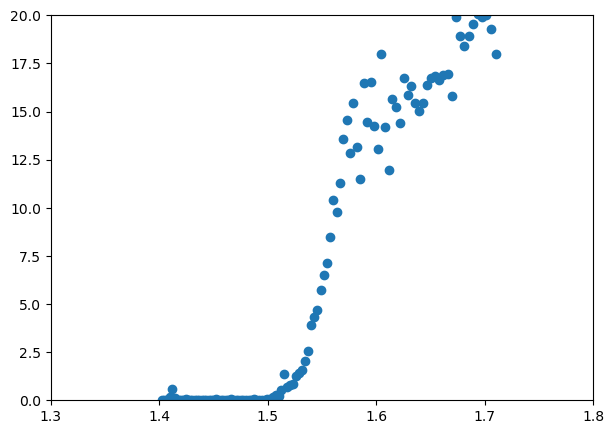

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(tauc_x, tauc_intensity)
#plt.yscale("log")
plt.xlim(1.3, 1.8)
plt.ylim(0,20)

(-5.0, 5.0)

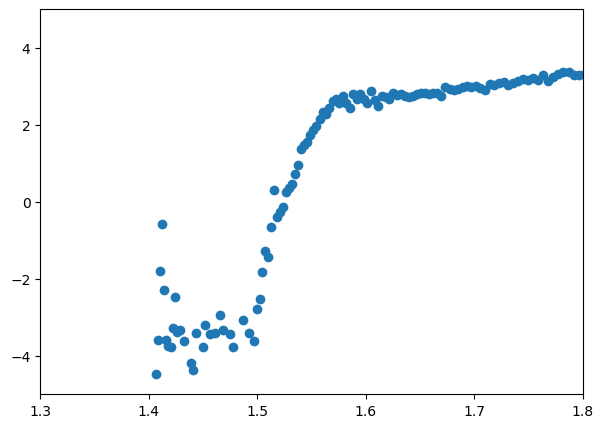

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(tauc_x, np.log(tauc_intensity))
#plt.yscale("log")
plt.xlim(1.3, 1.8)
plt.ylim(-5,5)

In [ ]:
"""Solar simulator comparison utility for CsI samples.

Replicates the workflow of ``MA_antiSolvent_Compare.ipynb`` as a pure Python script.
Update ``FOLDER_PATH`` or ``GROUPS`` with the locations of your measurement folders
before executing this script.
"""

from __future__ import annotations

import argparse
import math
import os
from datetime import datetime
from pathlib import Path
from typing import Mapping, Sequence

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import pandas as pd
import seaborn as sns

from plot_module.solsim_analyzer import solarSimulator

sns.set(style="whitegrid", context="talk")

# Provide either a base folder that contains one sub-folder per sample or
# specify absolute/relative paths per group inside ``GROUPS``.
FOLDER_PATH: str = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Thickness_C60/Selected_Data'
GROUPS: dict[str, str] = {
    "40nm C60": '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Thickness_C60/Selected_Data/40nm_C60',
    "30nm C60": '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Thickness_C60/Selected_Data/30nm_C60',
}

METRIC_ORDER: Sequence[str] = ("Voc", "Isc", "FF", "PCE")
FF_METRIC = "FF"
INDIVIDUAL_METRICS: Sequence[str] = ("Voc", "Isc", "FF", "PCE")
METRIC_LABELS = {
    "Voc": "Voc [V]",
    "Isc": "Isc [mA/cm²]",
    "FF": "FF (%)",
    "PCE": "PCE (%)",
    "Rs": "Rs [Ω]",
    "Rp": "Rp [Ω]",
}


def parse_arguments() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Compare solar-simulator metrics across CsI sample groups.",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    parser.add_argument(
        "--folder",
        default=FOLDER_PATH,
        help="Base directory that contains the measurement sub-folders.",
    )
    parser.add_argument(
        "--group",
        action="append",
        default=[],
        metavar="LABEL=PATH",
        help="Override or add a group mapping (can be passed multiple times).",
    )
    parser.add_argument(
        "--save",
        default=None,
        help="Directory where plots are written instead of showing interactively.",
    )
    parser.add_argument(
        "--no-show",
        action="store_true",
        help="Do not call plt.show(); helpful for headless runs.",
    )
    return parser.parse_args()


def parse_group_overrides(entries: Sequence[str]) -> dict[str, str]:
    overrides: dict[str, str] = {}
    for raw_entry in entries:
        if "=" not in raw_entry:
            raise SystemExit(f"Invalid --group entry '{raw_entry}'. Use LABEL=PATH format.")
        label, path = raw_entry.split("=", 1)
        label = label.strip()
        path = path.strip()
        if not label or not path:
            raise SystemExit(f"Invalid --group entry '{raw_entry}'. Label and path must be non-empty.")
        overrides[label] = path
    return overrides


def resolve_group_paths(base_folder: str, mapping: Mapping[str, str]) -> dict[str, Path]:
    resolved: dict[str, Path] = {}
    base_dir = Path(base_folder).expanduser() if base_folder else None

    for label, folder in mapping.items():
        candidate: Path | None = None
        if folder:
            candidate = Path(folder).expanduser()
        elif base_dir is not None:
            candidate = base_dir / label
        if candidate is None:
            continue
        resolved[label] = candidate

    if not resolved and base_dir is not None and base_dir.is_dir():
        for child in sorted(base_dir.iterdir()):
            if child.is_dir():
                resolved[child.name] = child

    return resolved


def load_group_analyzers(group_paths: Mapping[str, Path]) -> dict[str, solarSimulator]:
    analyzers: dict[str, solarSimulator] = {}
    for label, folder in group_paths.items():
        if not folder.is_dir():
            print(f"Skipping {label}: directory not found -> {folder}")
            continue
        if not any(folder.glob("*.dat")):
            print(f"Skipping {label}: no .dat files in {folder}")
            continue
        analyzer = solarSimulator(folderPath=str(folder))
        try:
            analyzer.loadFolderData()
        except Exception as exc:
            print(f"Skipping {label}: failed to load data ({exc})")
            continue
        analyzers[label] = analyzer
    return analyzers


def build_metric_frame(analyzers: Mapping[str, solarSimulator]) -> pd.DataFrame:
    rows: list[dict[str, float | str]] = []
    for label, analyzer in analyzers.items():
        metrics = {
            "Isc": analyzer.Isc,
            "Voc": analyzer.Voc,
            "FF": analyzer.FF,
            "PCE": analyzer.PCE,
        }
        for resistance_metric in ("Rs", "Rp"):
            resistance_values = getattr(analyzer, resistance_metric, None)
            if resistance_values is not None:
                metrics[resistance_metric] = resistance_values
        invalid_measurements: set[int] = set()
        for measurement_index, value in enumerate(metrics.get("PCE", []), start=1):
            try:
                numeric_pce = float(value)
            except (TypeError, ValueError):
                invalid_measurements.add(measurement_index)
                continue
            if not math.isfinite(numeric_pce) or numeric_pce < 1:
                invalid_measurements.add(measurement_index)

        for metric_name, values in metrics.items():
            for measurement_index, value in enumerate(values, start=1):
                if measurement_index in invalid_measurements:
                    continue
                try:
                    numeric = float(value)
                except (TypeError, ValueError):
                    continue
                if not math.isfinite(numeric):
                    continue
                rows.append({
                    "Group": label,
                    "Metric": metric_name,
                    "Measurement": measurement_index,
                    "Value": numeric,
                })
    if not rows:
        raise RuntimeError("No metrics available; check your folder paths.")

    frame = pd.DataFrame(rows)
    ff_mask = frame["Metric"] == FF_METRIC
    frame.loc[ff_mask, "Value"] = frame.loc[ff_mask, "Value"] * 100.0
    return frame


def log_metrics_to_csv(
    analyzers: Mapping[str, solarSimulator],
    filename: str = "metrics_summary.csv",
) -> None:
    for label, analyzer in analyzers.items():
        folder_path = getattr(analyzer, "folderPath", None)
        if not folder_path:
            print(f"Skipping {label}: analyzer has no folderPath defined.")
            continue
        if not analyzer.labels:
            print(f"Skipping {label}: no measurements were loaded for this group.")
            continue

        sample_count = len(analyzer.labels)

        def _normalise(values: Sequence[float] | None) -> list[float | None]:
            if values is None:
                return [None] * sample_count
            normalised = []
            for value in values:
                try:
                    numeric = float(value)
                except (TypeError, ValueError):
                    numeric = None
                if numeric is None or not math.isfinite(numeric):
                    normalised.append(None)
                else:
                    normalised.append(numeric)
            if len(normalised) < sample_count:
                normalised.extend([None] * (sample_count - len(normalised)))
            elif len(normalised) > sample_count:
                normalised = normalised[:sample_count]
            return normalised

        ff_percent = []
        for raw_ff in analyzer.FF:
            try:
                numeric_ff = float(raw_ff) if raw_ff is not None else None
            except (TypeError, ValueError):
                numeric_ff = None
            if numeric_ff is None or not math.isfinite(numeric_ff):
                ff_percent.append(None)
            else:
                ff_percent.append(numeric_ff * 100.0)
        if len(ff_percent) < sample_count:
            ff_percent.extend([None] * (sample_count - len(ff_percent)))
        elif len(ff_percent) > sample_count:
            ff_percent = ff_percent[:sample_count]

        data = {
            "Group": [label] * sample_count,
            "Sample": analyzer.labels,
            "Voc [V]": _normalise(analyzer.Voc),
            "Isc [mA/cm²]": _normalise(analyzer.Isc),
            "I_MPP [mA/cm²]": _normalise(analyzer.I_MPP),
            "V_MPP [V]": _normalise(analyzer.V_MPP),
            "FF [%]": ff_percent,
            "PCE [%]": _normalise(analyzer.PCE),
            "Rs [Ω]": _normalise(getattr(analyzer, "Rs", None)),
            "Rp [Ω]": _normalise(getattr(analyzer, "Rp", None)),
        }

        try:
            frame = pd.DataFrame(data)
        except ValueError as exc:
            print(f"Skipping {label}: failed to align metric lengths ({exc}).")
            continue

        output_path = Path(folder_path).expanduser() / filename
        try:
            frame.to_csv(output_path, index=False)
            print(f"Logged metrics for {label}: {output_path}")
        except Exception as exc:
            print(f"Failed to log metrics for {label}: {exc}")


def _sanitize_label_for_filename(label: str) -> str:
    sanitized = "".join(char if char.isalnum() or char in {"-", "_"} else "_" for char in label)
    sanitized = sanitized.strip("_")
    return sanitized or "group"


def export_metric_tables(
    frame: pd.DataFrame,
    groups_order: Sequence[str],
    output_dir: Path | None,
    subfolder: str = "metrics",
    combined_filename: str = "all_metrics.csv",
) -> None:
    if output_dir is None:
        return

    metrics_dir = output_dir / subfolder if subfolder else output_dir
    metrics_dir.mkdir(parents=True, exist_ok=True)

    combined_frame = frame.sort_values(["Group", "Metric", "Measurement"])
    combined_path = metrics_dir / combined_filename
    combined_frame.to_csv(combined_path, index=False)

    for group in groups_order:
        group_frame = combined_frame[combined_frame["Group"] == group]
        if group_frame.empty:
            continue
        pivot = group_frame.pivot_table(
            index="Measurement",
            columns="Metric",
            values="Value",
            aggfunc="first",
        ).sort_index()

        ordered_metrics = [metric for metric in METRIC_ORDER if metric in pivot.columns]
        remaining_metrics = [metric for metric in pivot.columns if metric not in ordered_metrics]
        if ordered_metrics or remaining_metrics:
            pivot = pivot[ordered_metrics + remaining_metrics]
        pivot.index.name = "Measurement"

        filename = f"{_sanitize_label_for_filename(group)}_metrics.csv"
        pivot.to_csv(metrics_dir / filename)

    print(f"Metric tables written to {metrics_dir}")


def show_group_means(frame: pd.DataFrame) -> None:
    means = frame.groupby(["Metric", "Group"])["Value"].mean().unstack("Group")
    print("\nGroup means (FF already converted to %):")
    print(means.round(3).to_string())
    print()


def choose_palette(labels: Sequence[str]) -> list[str]:
    custom = {
        "40nm C60": "#1f77b4",  # blue
        "30nm C60": "#d62728",  # red
    }

    fallback_palette = sns.color_palette("colorblind", max(len(labels), len(custom)))
    palette: list[str] = []

    fallback_iter = iter(fallback_palette)
    for label in labels:
        color = custom.get(label)
        if color is None:
            color = to_hex(next(fallback_iter))
        palette.append(color)
    return palette


def plot_metric_boxplots(
    frame: pd.DataFrame,
    groups_order: Sequence[str],
    palette: Sequence[str],
    output_dir: Path | None,
    subfolder: str = "boxplots",
    filename: str = "result.png",
) -> None:
    metrics_present = [metric for metric in METRIC_ORDER if metric in frame["Metric"].unique()]
    if not metrics_present:
        return

    cols = 2
    rows = math.ceil(len(metrics_present) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows), dpi=150)
    if isinstance(axes, plt.Axes):  # single axis case
        axes = [axes]
    else:
        axes = axes.ravel()

    for ax, metric in zip(axes, metrics_present):
        subset = frame[frame["Metric"] == metric]
        if subset.empty:
            ax.axis("off")
            continue
        sns.boxplot(
            data=subset,
            x="Group",
            y="Value",
            order=groups_order,
            palette=palette,
            ax=ax,
        )
        sns.stripplot(
            data=subset,
            x="Group",
            y="Value",
            order=groups_order,
            color="black",
            size=3,
            jitter=True,
            alpha=0.6,
            ax=ax,
        )
        ax.set_xlabel("")
        label = METRIC_LABELS.get(metric, metric)
        ax.set_ylabel(label)
        if metric == FF_METRIC:
            ax.set_ylim(0, 100)
        ax.set_title(f"{metric} comparison")
        ax.grid(True, axis="y", alpha=0.3)
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
            tick.set_ha("right")

    # Hide any unused axes due to missing metrics
    for index in range(len(metrics_present), len(axes)):
        axes[index].axis("off")

    plt.tight_layout()

    if output_dir is not None:
        target_dir = output_dir / subfolder if subfolder else output_dir
        target_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(target_dir / filename, dpi=300)

    plt.close(fig)


def plot_best_iv_curves(
    analyzers: Mapping[str, solarSimulator],
    groups_order: Sequence[str],
    palette: Sequence[str],
    output_dir: Path | None,
    subfolder: str = "iv_curves",
    filename: str = "result.png",
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    color_map = dict(zip(groups_order, palette))

    for label in groups_order:
        analyzer = analyzers.get(label)
        if analyzer is None or not analyzer.PCE:
            continue
        best_idx = max(range(len(analyzer.PCE)), key=lambda idx: analyzer.PCE[idx])
        voltages = -analyzer.voltages[best_idx]
        currents = analyzer.currents[best_idx]
        ax.plot(
            voltages,
            currents,
            label=label,
            color=color_map.get(label),
            linewidth=2.2,
        )

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("Current density (mA/cm^2)")
    ax.set_ylim(-1, 20)
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if output_dir is not None:
        target_dir = output_dir / subfolder if subfolder else output_dir
        target_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(target_dir / filename, dpi=300)

    plt.close(fig)


def plot_single_metric_boxplot(
    metric: str,
    frame: pd.DataFrame,
    groups_order: Sequence[str],
    palette: Sequence[str],
    output_dir: Path | None,
    base_subfolder: str = "boxplots",
    filename: str = "result.png",
) -> None:
    subset = frame[frame["Metric"] == metric]
    if subset.empty:
        return

    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    sns.boxplot(
        data=subset,
        x="Group",
        y="Value",
        order=groups_order,
        palette=palette,
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x="Group",
        y="Value",
        order=groups_order,
        color="black",
        size=4,
        jitter=True,
        alpha=0.7,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    if metric == FF_METRIC:
        ax.set_ylim(0, 100)
    ax.set_title(f"{metric} comparison")
    ax.grid(True, axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha("right")

    plt.tight_layout()

    if output_dir is not None:
        target_dir = output_dir / base_subfolder / metric
        target_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(target_dir / filename, dpi=300)

    plt.close(fig)


def main() -> None:
    args = parse_arguments()
    group_mapping = dict(GROUPS)
    group_mapping.update(parse_group_overrides(args.group))
    group_paths = resolve_group_paths(args.folder, group_mapping)
    if not group_paths:
        raise SystemExit("No group directories resolved. Update FOLDER_PATH or supply --group arguments.")

    analyzers = load_group_analyzers(group_paths)
    if not analyzers:
        raise SystemExit("No analyzers created. Ensure the folders contain .dat files.")

    frame = build_metric_frame(analyzers)
    log_metrics_to_csv(analyzers)
    show_group_means(frame)

    groups_order = [label for label in group_paths if label in analyzers]
    palette = choose_palette(groups_order)
    output_dir = Path(args.save).expanduser() if args.save else None
    auto_output_dir = False
    if output_dir is None:
        auto_output_dir = True
        candidate_dirs = [path for path in group_paths.values()]
        base_dir: Path
        if args.folder:
            base_dir = Path(args.folder).expanduser()
        else:
            try:
                base_dir = Path(os.path.commonpath([str(path.parent) for path in candidate_dirs]))
            except ValueError:
                base_dir = candidate_dirs[0].parent
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_dir = base_dir / f"Result+{timestamp}"

    export_metric_tables(frame, groups_order, output_dir)
    plot_metric_boxplots(frame, groups_order, palette, output_dir)
    for metric in INDIVIDUAL_METRICS:
        plot_single_metric_boxplot(metric, frame, groups_order, palette, output_dir)
    plot_best_iv_curves(analyzers, groups_order, palette, output_dir)

    if auto_output_dir:
        print(f"Plots saved to {output_dir}")


if __name__ == "__main__":
    main()
